In [48]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [50]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard (2).csv


In [51]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [52]:
# basic info
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [53]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [54]:
#main challenge
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


**PART 2: VISUALIZATION and EDA**




In [55]:
#to clean data by removing all null values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


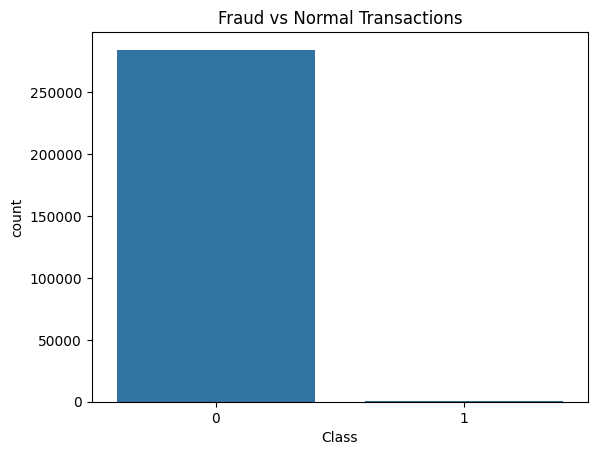

In [56]:
#class distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

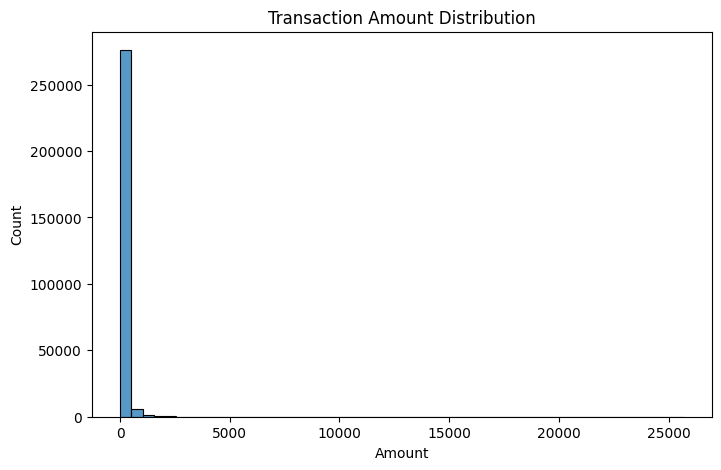

In [57]:
#analyzing transaction amount
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

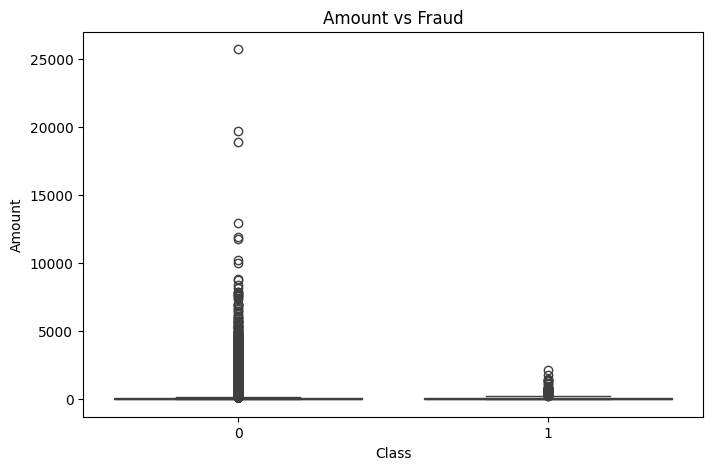

In [58]:
#fraud vs amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

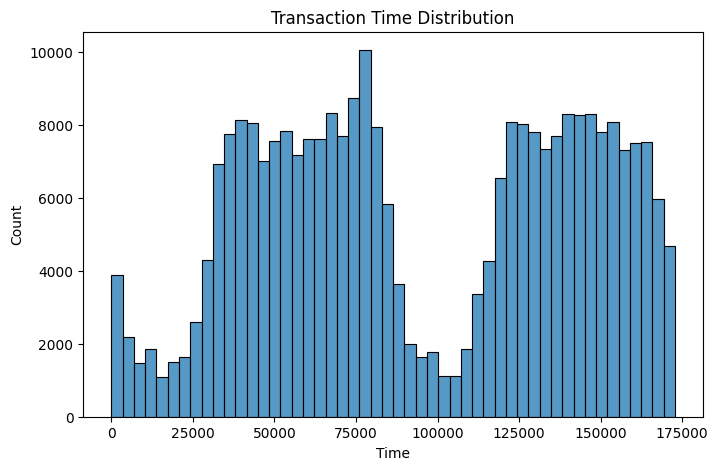

In [60]:
#Transactions vary across time (not uniform)
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

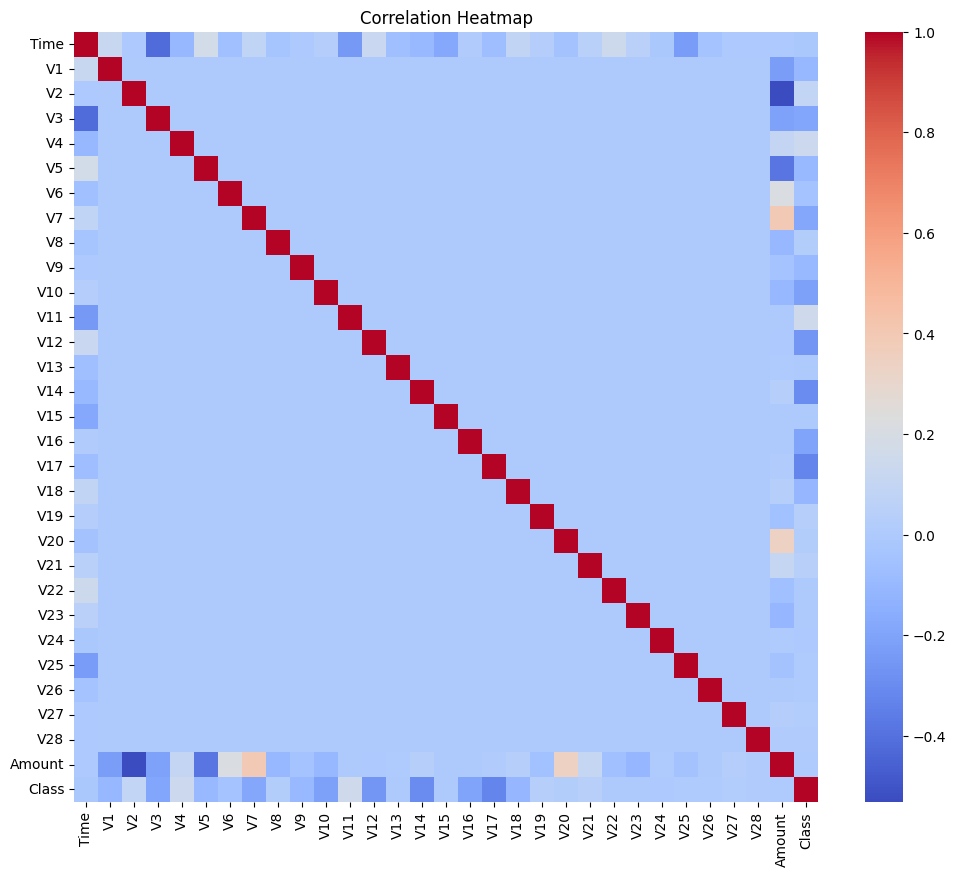

In [61]:
#correlation heatmap
# can be useful for feature importance
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [62]:
#fraud percentage
fraud_percentage = df['Class'].value_counts(normalize=True)[1] * 100
print(f"Fraud Transactions: {fraud_percentage:.4f}%")

Fraud Transactions: 0.1727%


The dataset is highly imbalanced with only 0.17% fraud cases




**step 3: Data Preprocessing + Handling Imbalance**

In [63]:
X = df.drop('Class', axis=1)
y = df['Class']

In [64]:
#split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
#checking imbalance in training data
y_train.value_counts()

,count
Class,
0,227451
1,394


lets use SMOTE to detect fake fraud samples to balance data

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [67]:
y_train_res.value_counts()
# if 0 and 1 values are equal then data is balanced

,count
Class,
0,227451
1,227451


**STEP4 : Train ML Models**

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=20, n_jobs=-1, random_state=42)

In [69]:
y_pred_rf = rf_model.predict(X_test)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [72]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    solver='liblinear'
)
lr_model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=2000, solver='liblinear')

In [73]:
y_pred_lr = lr_model.predict(X_test)

**STEP 5: Model Evaluation**

In [74]:
from sklearn.metrics import classification_report, confusion_matrix

In [75]:
#evaluate both logistic regression and random forest models

from sklearn.metrics import classification_report

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.91      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.63     56962
weighted avg       1.00      0.99      0.99     56962


Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



OBSERVATIONS & INSIGHTS


1. The dataset is highly imbalanced (~0.17% fraud cases), so accuracy is not a reliable metric.

2. Logistic Regression:
   - High Recall (0.91): Able to detect most fraudulent transactions.
   - Low Precision (0.16): Many false positives (normal transactions flagged as fraud).
   - Suitable when missing fraud is very costly.

3. Random Forest:
   - High Precision (0.90): Most predicted fraud cases are correct.
   - Low Recall (0.18): Misses many fraud cases.
   - More conservative model.

4. Key Trade-off:
   - Logistic Regression → High Recall, Low Precision
   - Random Forest → High Precision, Low Recall

5. Conclusion:
   In fraud detection, recall is more important than precision because
   missing a fraudulent transaction can lead to financial loss.

   Therefore, Logistic Regression is preferred in this case.

6. Future Improvement:
   - Tune Random Forest with class_weight='balanced'
   - Try other models like XGBoost
   - Adjust threshold to balance precision and recall
